Case 1: HR from Wrist (Empatica E4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
hr_df = pd.read_csv("../data/raw/WESAD/S2/S2_E4_Data/HR.csv", header=None)

print(hr_df.head())
print(hr_df.shape)

              0
0  1.495437e+09
1  1.000000e+00
2  1.010000e+02
3  1.065000e+02
4  9.533000e+01
(7867, 1)


Extract the actual HR signal:

In [2]:
fs = float(hr_df.iloc[1,0])      # should be 1 Hz
hr = hr_df.iloc[2:,0].astype(float).values

print("Sampling Frequency:", fs)
print("HR Shape:", hr.shape)

Sampling Frequency: 1.0
HR Shape: (7865,)


Plot Raw HR

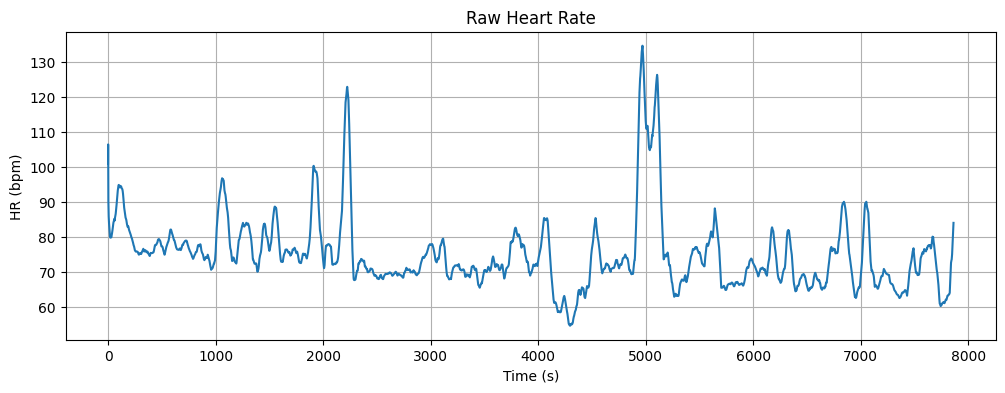

In [3]:
plt.figure(figsize=(12,4))
plt.plot(hr)

plt.title("Raw Heart Rate")
plt.xlabel("Time (s)")
plt.ylabel("HR (bpm)")
plt.grid(True)

plt.show()

Smooth HR(moving average)

In [4]:
window = 5

hr_filtered = np.convolve(
    hr,
    np.ones(window)/window,
    mode='same'
)

Compare Raw vs Smoothed HR

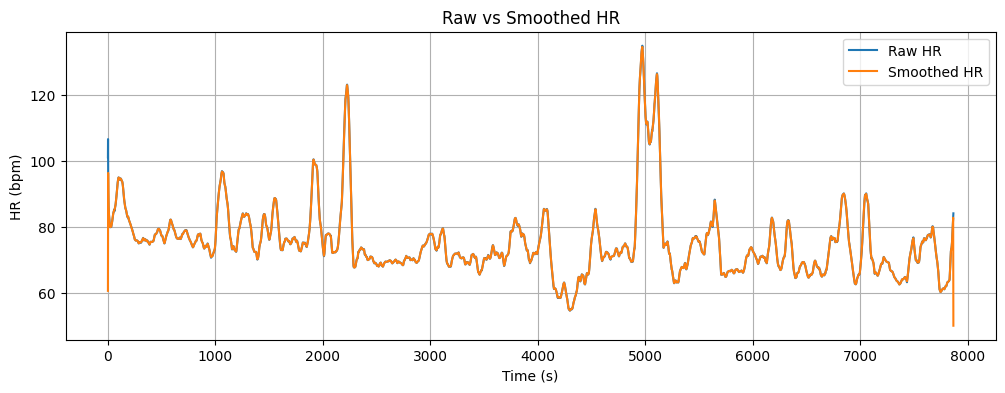

In [5]:
plt.figure(figsize=(12,4))

plt.plot(hr, label="Raw HR")
plt.plot(hr_filtered, label="Smoothed HR")

plt.title("Raw vs Smoothed HR")
plt.xlabel("Time (s)")
plt.ylabel("HR (bpm)")
plt.legend()
plt.grid(True)

plt.show()

Evaluate Filtering

In [6]:
raw_z = np.abs((hr - np.mean(hr))/np.std(hr))
filtered_z = np.abs((hr_filtered - np.mean(hr_filtered))/np.std(hr_filtered))

raw_spikes = np.sum(raw_z > 3)
filtered_spikes = np.sum(filtered_z > 3)

noise_raw = np.std(np.diff(hr))
noise_filtered = np.std(np.diff(hr_filtered))

print("RAW HR")
print("Mean:", np.mean(hr))
print("Std :", np.std(hr))
print("Spikes:", raw_spikes)
print("Noise :", noise_raw)

print("\nFILTERED HR")
print("Mean:", np.mean(hr_filtered))
print("Std :", np.std(hr_filtered))
print("Spikes:", filtered_spikes)
print("Noise :", noise_filtered)

RAW HR
Mean: 75.09649459631277
Std : 10.736697505251097
Spikes: 224
Noise : 0.3000398582891357

FILTERED HR
Mean: 75.08225657978386
Std : 10.726782030724564
Spikes: 223
Noise : 0.46431343752911514
